# MetaCal – BMR-Based Calorie Prediction Using Machine Learning

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
Df=pd.read_csv('nutritional_data.csv')
Df

,Gender,Age,Daily Meal Frequency,Physical Exercise,Height,Weight,BMR,Carbs,Proteins,Fats,Calories
0,0,29,3,0,165,101.0,1901.25,285.188,114.075,76.050,2281.502
1,1,25,3,4,165,53.0,1275.25,302.872,121.149,80.766,2422.978
2,0,23,2,0,170,70.0,1652.50,247.875,99.150,66.100,1983.000
3,0,22,3,0,168,112.0,2065.00,309.750,123.900,82.600,2478.000
4,0,19,3,2,175,67.0,1673.75,324.289,129.716,86.477,2594.313
...,...,...,...,...,...,...,...,...,...,...,...
11995,0,22,2,3,170,65.0,1639.10,205.000,109.000,58.000,1778.000
11996,0,29,2,4,173,83.0,1749.20,233.000,114.000,74.000,2054.000
11997,1,55,3,0,142,111.0,1624.60,304.000,83.000,79.000,2259.000
11998,0,29,3,0,171,50.0,1416.20,197.000,65.000,48.000,1480.000


In [3]:
Df.shape

(12000, 11)

In [4]:
Df.isnull().sum()

Gender                  0
Age                     0
Daily Meal Frequency    0
Physical Exercise       0
Height                  0
Weight                  0
BMR                     0
Carbs                   0
Proteins                0
Fats                    0
Calories                0
dtype: int64

In [5]:
Df.dtypes

Gender                    int64
Age                       int64
Daily Meal Frequency      int64
Physical Exercise         int64
Height                    int64
Weight                  float64
BMR                     float64
Carbs                   float64
Proteins                float64
Fats                    float64
Calories                float64
dtype: object

In [6]:
Df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gender                12000 non-null  int64  
 1   Age                   12000 non-null  int64  
 2   Daily Meal Frequency  12000 non-null  int64  
 3   Physical Exercise     12000 non-null  int64  
 4   Height                12000 non-null  int64  
 5   Weight                12000 non-null  float64
 6   BMR                   12000 non-null  float64
 7   Carbs                 12000 non-null  float64
 8   Proteins              12000 non-null  float64
 9   Fats                  12000 non-null  float64
 10  Calories              12000 non-null  float64
dtypes: float64(6), int64(5)
memory usage: 1.0 MB


In [7]:
Df.describe

<bound method NDFrame.describe of        Gender  Age  Daily Meal Frequency  Physical Exercise  Height  Weight  \
0           0   29                     3                  0     165   101.0   
1           1   25                     3                  4     165    53.0   
2           0   23                     2                  0     170    70.0   
3           0   22                     3                  0     168   112.0   
4           0   19                     3                  2     175    67.0   
...       ...  ...                   ...                ...     ...     ...   
11995       0   22                     2                  3     170    65.0   
11996       0   29                     2                  4     173    83.0   
11997       1   55                     3                  0     142   111.0   
11998       0   29                     3                  0     171    50.0   
11999       1   46                     3                  1     160    48.0   

           BMR   

In [8]:
data=Df
data

,Gender,Age,Daily Meal Frequency,Physical Exercise,Height,Weight,BMR,Carbs,Proteins,Fats,Calories
0,0,29,3,0,165,101.0,1901.25,285.188,114.075,76.050,2281.502
1,1,25,3,4,165,53.0,1275.25,302.872,121.149,80.766,2422.978
2,0,23,2,0,170,70.0,1652.50,247.875,99.150,66.100,1983.000
3,0,22,3,0,168,112.0,2065.00,309.750,123.900,82.600,2478.000
4,0,19,3,2,175,67.0,1673.75,324.289,129.716,86.477,2594.313
...,...,...,...,...,...,...,...,...,...,...,...
11995,0,22,2,3,170,65.0,1639.10,205.000,109.000,58.000,1778.000
11996,0,29,2,4,173,83.0,1749.20,233.000,114.000,74.000,2054.000
11997,1,55,3,0,142,111.0,1624.60,304.000,83.000,79.000,2259.000
11998,0,29,3,0,171,50.0,1416.20,197.000,65.000,48.000,1480.000


In [9]:
x = data.drop(["Calories", "Fats"], axis=1)
y = data["Calories"]

In [10]:
x

,Gender,Age,Daily Meal Frequency,Physical Exercise,Height,Weight,BMR,Carbs,Proteins
0,0,29,3,0,165,101.0,1901.25,285.188,114.075
1,1,25,3,4,165,53.0,1275.25,302.872,121.149
2,0,23,2,0,170,70.0,1652.50,247.875,99.150
3,0,22,3,0,168,112.0,2065.00,309.750,123.900
4,0,19,3,2,175,67.0,1673.75,324.289,129.716
...,...,...,...,...,...,...,...,...,...
11995,0,22,2,3,170,65.0,1639.10,205.000,109.000
11996,0,29,2,4,173,83.0,1749.20,233.000,114.000
11997,1,55,3,0,142,111.0,1624.60,304.000,83.000
11998,0,29,3,0,171,50.0,1416.20,197.000,65.000


In [11]:
y

0        2281.502
1        2422.978
2        1983.000
3        2478.000
4        2594.313
           ...   
11995    1778.000
11996    2054.000
11997    2259.000
11998    1480.000
11999    1326.000
Name: Calories, Length: 12000, dtype: float64

# EDA

# Target Variable Distribution

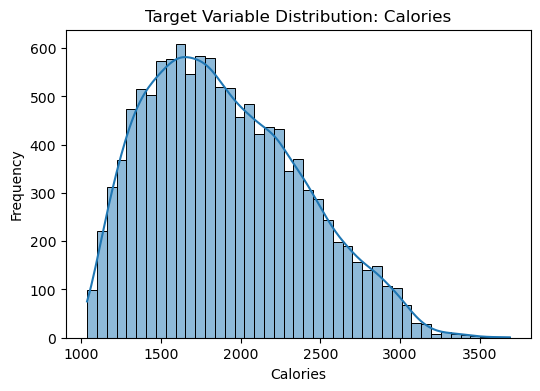

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(Df['Calories'], kde=True)
plt.title('Target Variable Distribution: Calories')
plt.xlabel('Calories')
plt.ylabel('Frequency')
plt.show()


In [13]:
x = data.drop(["Calories", "Fats"], axis=1)
y=data["Calories"]

# Scatter Plots → Feature vs Target

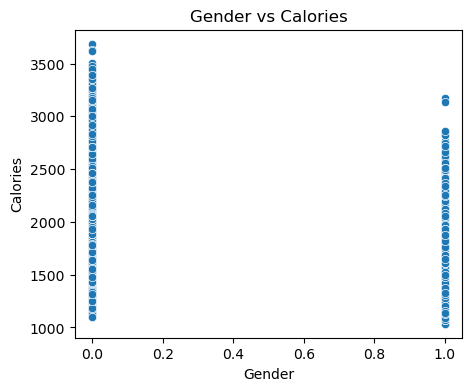

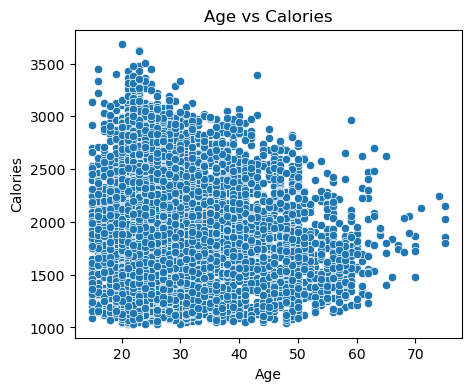

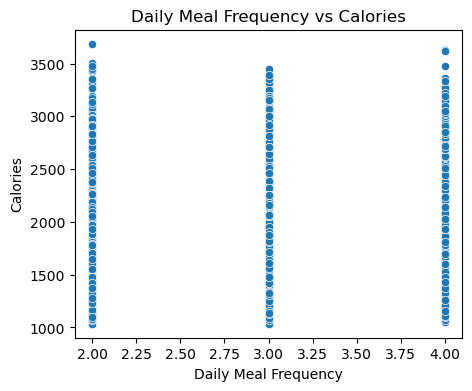

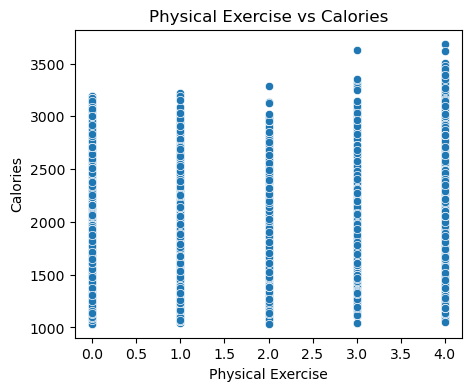

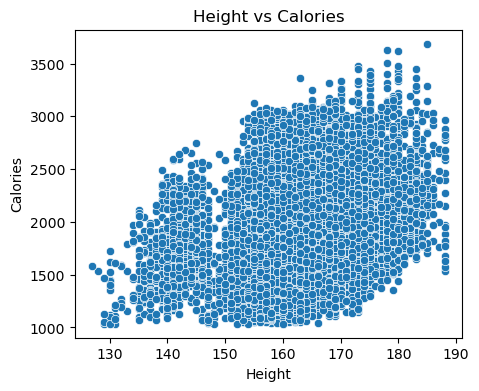

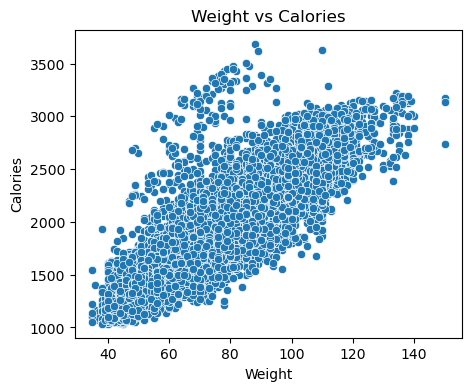

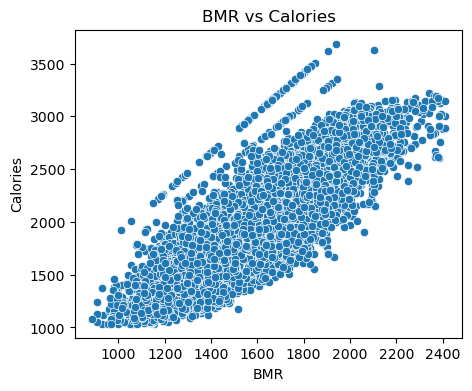

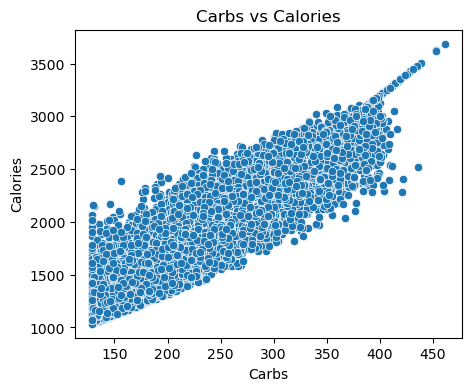

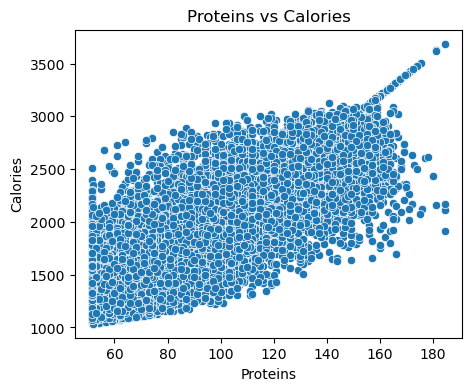

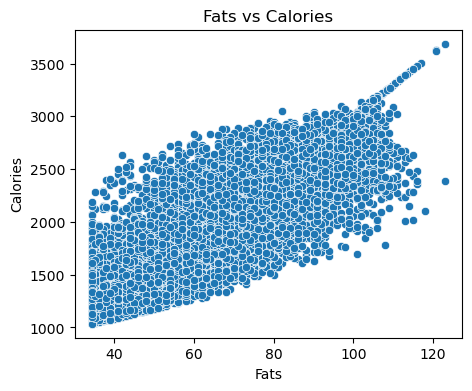

In [14]:
numerical_features = Df.select_dtypes(include=np.number).columns
numerical_features = numerical_features.drop('Calories')

for feature in numerical_features:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=Df[feature], y=Df['Calories'])
    plt.title(f'{feature} vs Calories')
    plt.xlabel(feature)
    plt.ylabel('Calories')
    plt.show()


# Correlation Heatmap → Feature Selection

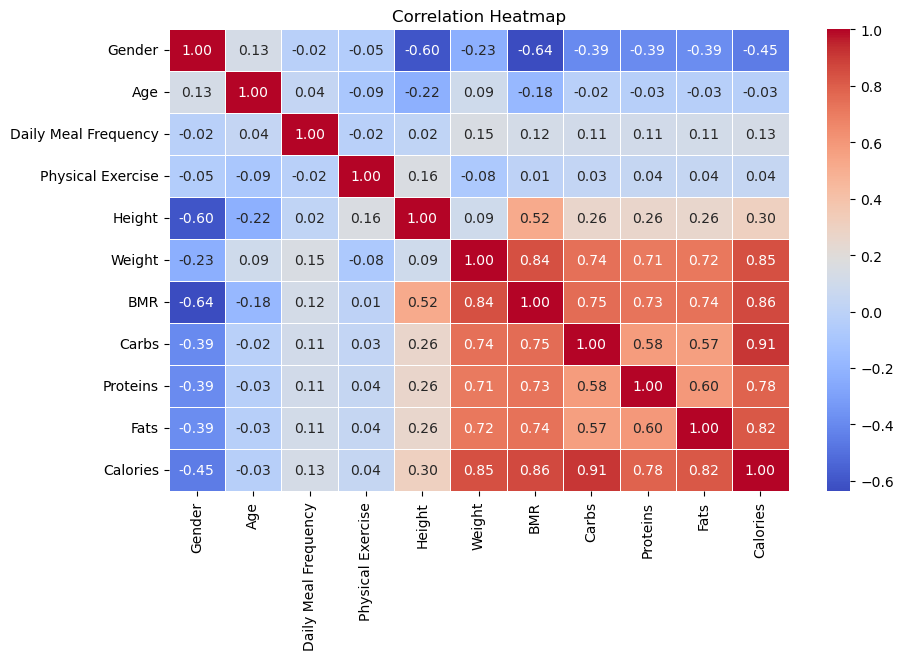

In [15]:
plt.figure(figsize=(10,6))
corr = Df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()


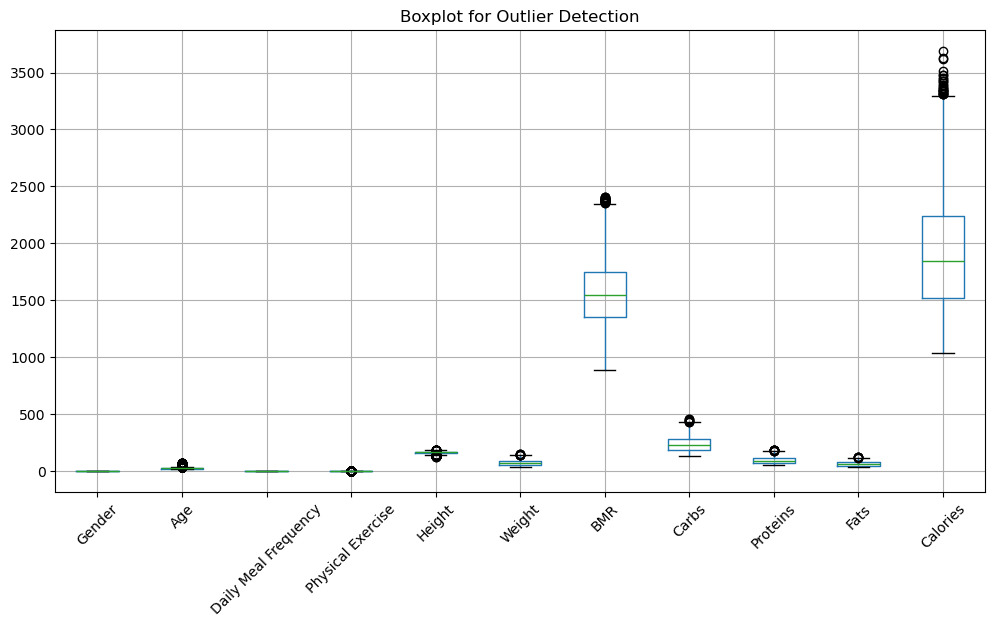

In [12]:
plt.figure(figsize=(12,6))
Df.boxplot()
plt.xticks(rotation=45)
plt.title('Boxplot for Outlier Detection')
plt.show()


In [13]:
def iqr_outlier_capping(df):
    df_capped = df.copy()
    
    for col in df_capped.select_dtypes(include=np.number).columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_capped[col] = np.where(
            df_capped[col] < lower_bound,
            lower_bound,
            np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])
        )
        
    return df_capped


In [14]:
Df_capped = iqr_outlier_capping(Df)


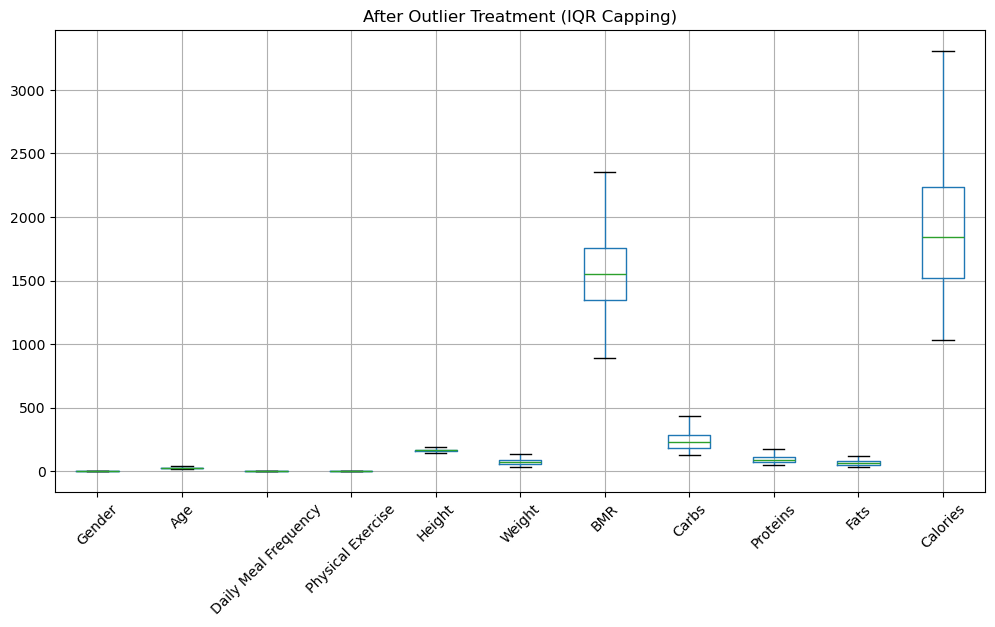

In [15]:
plt.figure(figsize=(12,6))
Df_capped.select_dtypes(include=np.number).boxplot()
plt.xticks(rotation=45)
plt.title('After Outlier Treatment (IQR Capping)')
plt.show()


# Train Test Split

In [20]:
x = Df_capped.drop(["Calories", "Fats"], axis=1)
y = Df_capped['Calories']


In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

In [23]:
models = {
    'LinearRegression': LinearRegression(),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR(kernel='rbf', C=10, gamma='scale'),
    'DecisionTree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=3, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8, random_state=42),
    'AdaBoost': AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4, random_state=42),
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )
}

# -------------------------------
#  Evaluate each model
# -------------------------------
results = []
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    # Choose scaled or original features
    if name in ['KNN', 'LinearRegression', 'SVR']:
        X_train, X_test = x_train_scaled, x_test_scaled
    else:
        X_train, X_test = x_train, x_test
    
    # Fit model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_test = r2_score(y_test, y_pred)
    # r2_train: use model.score on training set (consistent with original script)
    r2_train = model.score(X_train, y_train)
    
    # Cross-validation R² (use the same training X chosen above
    cv_r2 = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2').mean()
    
    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Train': r2_train,
        'R2 Test': r2_test,
        'CV R2': cv_r2
    })

# -------------------------------
#  Display results
# -------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='R2 Test', ascending=False).reset_index(drop=True)
print(results_df)

              Model        MAE           MSE        RMSE  R2 Train   R2 Test  \
0      RandomForest  75.860932   9965.802111   99.828864  0.966882  0.957027   
1  GradientBoosting  80.274936  10289.685233  101.438086  0.958225  0.955631   
2  LinearRegression  84.260447  11698.042424  108.157489  0.948772  0.949558   
3          AdaBoost  89.635148  12459.482260  111.622051  0.947487  0.946275   
4               KNN  88.386042  13584.789916  116.553807  0.959092  0.941422   
5      DecisionTree  86.944721  14012.992554  118.376486  0.972975  0.939576   
6               SVR  90.719727  14514.305262  120.475331  0.936533  0.937414   

      CV R2  
0  0.955024  
1  0.953633  
2  0.948534  
3  0.943923  
4  0.936770  
5  0.936283  
6  0.932377  


# HyperParameter Tuning

### RandomForest

In [24]:
param_dist = {
    'n_estimators': [100, 200, 300, 500, 800, 1000],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Create the model
rf = RandomForestRegressor(random_state=42)

# Randomized Search (you can increase n_iter for more combinations)
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='r2'
)

# Fit model
rf_random.fit(x_train,y_train)

# Best parameters
print("Best Parameters:", rf_random.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15, 'bootstrap': True}


In [24]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_features='log2',
    max_depth=15,
    bootstrap=True,
    min_samples_leaf = 1,  # or 5
    min_samples_split = 10,  # or 10,  # or 5
    random_state=42
)

# Fit model
rf.fit(x_train, y_train)

# Predict
y_pred = rf.predict(x_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = rmse = np.sqrt(mse)
r2_test = r2_score(y_test, y_pred)
r2_train = model.score(X_train, y_train)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_r2 = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2').mean()

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Train:", r2_train)
print("R² Test:", r2_test)
print("Cross-Validation R²:", cv_r2)

MAE: 75.0512145062353
MSE: 9719.037910688336
RMSE: 98.58518098927615
R² Train: 0.9474872281668549
R² Test: 0.9580914642854043
Cross-Validation R²: 0.9439230715574609


### GradientBoost

In [28]:
param_grid = {
    'n_estimators': [200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'subsample': [0.7, 0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(gb, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(x_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

Best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 800, 'subsample': 0.7}
Best CV R²: 0.955753904757659


In [29]:
gbr = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=0.7,
    random_state=42
)

gbr.fit(x_train, y_train)
y_pred = gbr.predict(x_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = rmse = np.sqrt(mse)
r2_test = r2_score(y_test, y_pred)
r2_train = model.score(X_train, y_train)
cv_r2 = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2').mean()

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Train:", r2_train)
print("R² Test:", r2_test)
print("Cross-Validation R²:", cv_r2)

MAE: 76.6400172391046
MSE: 9677.506880738483
RMSE: 98.37432023012146
R² Train: 0.9474872281668549
R² Test: 0.9582705462756086
Cross-Validation R²: 0.9439230715574609


In [25]:
import joblib
joblib.dump(rf, 'best_model.pkl')
print("Model saved as 'best_model.pkl'")

Model saved as 'best_model.pkl'


In [26]:
# Load the saved model
calorie_model = joblib.load('best_model.pkl')
print("Model loaded successfully!")

Model loaded successfully!


In [27]:
# Use the loaded model to make predictions
ab=[[0,23,3,2,172,68,1645,250,600]]
y_pred = calorie_model.predict(ab)
print(y_pred)

[2137.05521141]
